<h1><center>EIE 401 - PROCESAMIENTO DIGITAL MULTIMEDIA</center></h1>
<h2><center>Actividad Integrada: Fundamentos, Muestreo y Casos de Aplicación</center></h2>
<center><h3>Profesor: Jorge Cardenas</h3></center>
<center><h3>Estudiante: Camilo Andres Ladino Morales</h3></center>
<center><h5>Pontificia Universidad Católica de Valparaíso</h5></center>

## 1. Perfil Profesional y Repositorio
El uso de herramientas de control de versiones y repositorios públicos es esencial. 

**Tarea:** Agrega tu usuario de GitHub y el enlace al repositorio que utilizarás para este curso.

In [1]:
# Usuario GitHub: camiloladinom-netizen
# Enlace Repositorio: https://github.com/camiloladinom-netizen/Procesamiento-digital-multimedia.git

## 2. Configuración del Entorno y Librerías
Importamos las librerías base para procesamiento de señales, análisis estadístico y visualización.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftfreq, fft2, fftshift, ifft2
import scipy.stats as stats

## 3. Distribuciones de Probabilidad y Ruido
En multimedia, el ruido no es solo 'error', es un fenómeno estocástico que puede modelarse matemáticamente.

**Tarea:**
1. Genera 10,000 muestras de una **Distribución Normal** (Gaussiana) con $\mu=0$ y $\sigma=1$. Grafica su histograma.
2. Crea una señal senoidal pura de 20 Hz.
3. Agrega el ruido gaussiano a la señal pura para obtener una señal contaminada.
4. Grafica la señal pura, el ruido solo, y la señal final resultante.

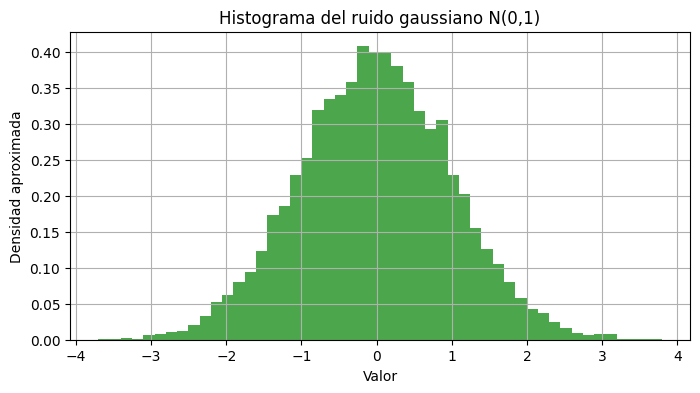

Explicación del histograma:
El histograma muestra la distribución de las 10.000 muestras de ruido gaussiano generadas.
Los valores se concentran alrededor de 0 y decrecen hacia los extremos, formando una campana
simétrica. Esto es consistente con una distribución normal estándar con media 0 y desviación
estándar 1, tal como se definió en los parámetros del ruido.


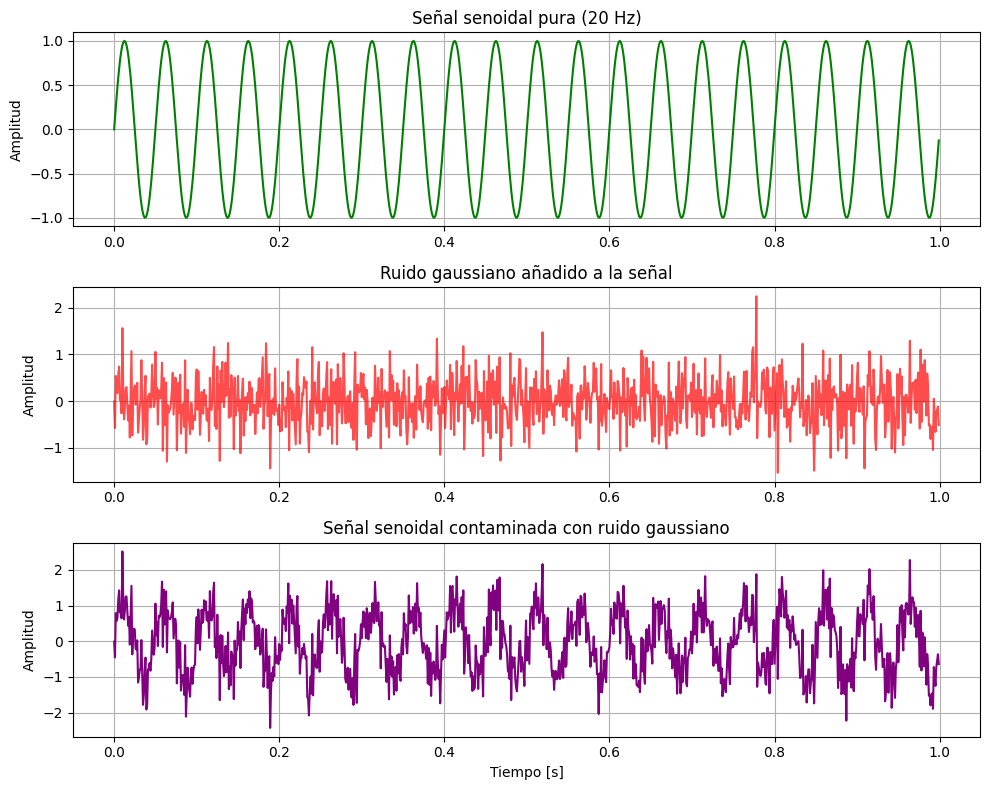


Explicación de las señales en el tiempo:
1) Señal senoidal pura (primer gráfico):
   Se observa una onda periódica suave de 20 Hz, con crestas y valles regulares.
   No hay fluctuaciones bruscas porque aún no se ha añadido ruido.

2) Ruido gaussiano (segundo gráfico):
   La traza es irregular y aparentemente impredecible. No presenta un patrón periódico,
   sino variaciones aleatorias alrededor de 0, determinadas por la desviación estándar
   elegida (σ = 0.5 para este ruido sobre la señal).

3) Señal contaminada (tercer gráfico):
   Aquí se ve la combinación de la senoidal pura de 20 Hz con el ruido gaussiano.
   Aún es posible reconocer la forma oscilatoria de la señal original, pero sus valores
   están perturbados en cada instante por el ruido, haciendo que algunas crestas aumenten
   o disminuyan y que la señal ya no sea perfectamente periódica en apariencia.



In [3]:
import numpy as np               # Importa NumPy para trabajar con arreglos numéricos (vectores, matrices, etc.).
import matplotlib.pyplot as plt  # Importa Matplotlib para crear gráficos (líneas, histogramas, etc.).

# -----------------------------
# 1) PARÁMETROS DEL RUIDO
# -----------------------------

mu = 0              # Media (μ) de la distribución normal del ruido. Valor promedio esperado del ruido.
sigma = 1           # Desviación estándar (σ). Controla qué tan dispersos están los valores alrededor de la media.
n_muestras = 10000  # Número total de muestras de ruido que se generarán para el histograma.

# -----------------------------
# 2) GENERACIÓN DEL RUIDO GAUSSIANO
# -----------------------------

ruido = np.random.normal(mu,     # Media de la distribución normal (μ).
                         sigma,  # Desviación estándar (σ).
                         n_muestras)  # Cantidad de valores aleatorios independientes que queremos.

# Ahora 'ruido' es un arreglo de tamaño 10000 con valores que siguen aproximadamente N(0,1).

# -----------------------------
# 3) HISTOGRAMA DEL RUIDO
# -----------------------------

plt.figure(figsize=(8, 4))   # Crea una nueva figura de tamaño 8x4 pulgadas.

plt.hist(ruido,              # Datos a representar en el histograma.
         bins=50,            # Número de barras (intervalos) en el histograma.
         density=True,       # Normaliza el histograma para aproximar la densidad de probabilidad.
         alpha=0.7,          # Transparencia de las barras.
         color='green')  # Color de las barras.

plt.title("Histograma del ruido gaussiano N(0,1)")  # Título del gráfico.
plt.xlabel("Valor")                                # Etiqueta del eje X.
plt.ylabel("Densidad aproximada")                  # Etiqueta del eje Y.
plt.grid(True)                                     # Activa la grilla para facilitar la lectura.
plt.show()                                         # Muestra el gráfico en pantalla.

# ---- TEXTO EXPLICATIVO DEL HISTOGRAMA ----
print("Explicación del histograma:")
print(
    "El histograma muestra la distribución de las 10.000 muestras de ruido gaussiano generadas.\n"
    "Los valores se concentran alrededor de 0 y decrecen hacia los extremos, formando una campana\n"
    "simétrica. Esto es consistente con una distribución normal estándar con media 0 y desviación\n"
    "estándar 1, tal como se definió en los parámetros del ruido."
)

# -----------------------------
# 4) PARÁMETROS DE LA SEÑAL SENOIDAL
# -----------------------------

fs = 1000             # Frecuencia de muestreo en Hz (muestras por segundo). Debe ser mayor que 2*20 para cumplir Nyquist.
duracion = 1.0        # Duración total de la señal en segundos.

t = np.linspace(0,                 # Tiempo inicial (0 segundos).
                duracion,          # Tiempo final (1 segundo).
                int(fs*duracion),  # Número total de puntos: fs * duración = 1000 puntos.
                endpoint=False)    # endpoint=False evita incluir exactamente el segundo final, mantiene el paso constante.

f_senal = 20          # Frecuencia de la señal senoidal pura en Hz.

# -----------------------------
# 5) CREACIÓN DE LA SEÑAL PURA
# -----------------------------

senal_pura = np.sin(2 * np.pi * f_senal * t)
# Crea una onda senoidal:
# - 2 * pi * f_senal: frecuencia en radianes por segundo.
# - Multiplicar por 't' da la fase en cada instante de tiempo.
# - sin(...) evalúa la función seno en cada punto de tiempo.

# -----------------------------
# 6) GENERACIÓN DE RUIDO PARA LA SEÑAL
# -----------------------------

sigma_ruido_senal = 0.5  # Desviación estándar del ruido que se sumará a la señal. Controla la intensidad del ruido.

ruido_senal = np.random.normal(0,                   # Media 0: ruido centrado (sin sesgo).
                               sigma_ruido_senal,   # Desviación estándar de este ruido.
                               len(t))              # Número de muestras de ruido igual al largo de la señal.

# 'ruido_senal' ahora tiene la misma cantidad de puntos que 'senal_pura',
# lo que permite sumarlos muestra a muestra.

# -----------------------------
# 7) CREACIÓN DE LA SEÑAL RUIDOSA
# -----------------------------

senal_ruidosa = senal_pura + ruido_senal
# Suma punto a punto:
# en cada instante de tiempo, la señal final es la senoidal pura más un valor aleatorio de ruido.

# -----------------------------
# 8) GRÁFICOS COMPARATIVOS
# -----------------------------

plt.figure(figsize=(10, 8))  # Crea una figura grande con 3 subgráficos verticales.

# 8.1) Señal senoidal pura
plt.subplot(3, 1, 1)                     # Primer subplot: 3 filas, 1 columna, posición 1.
plt.plot(t, senal_pura, color='green')   # Grafica la señal pura en verde.
plt.title("Señal senoidal pura (20 Hz)") # Título del primer gráfico.
plt.ylabel("Amplitud")                   # Etiqueta del eje Y.
plt.grid(True)                           # Activa la grilla.

# 8.2) Ruido gaussiano sobre la longitud de la señal
plt.subplot(3, 1, 2)                     # Segundo subplot: posición 2.
plt.plot(t, ruido_senal, color='red', alpha=0.7)  # Grafica el ruido en rojo.
plt.title("Ruido gaussiano añadido a la señal")   # Título del segundo gráfico.
plt.ylabel("Amplitud")                             # Etiqueta del eje Y.
plt.grid(True)                                     # Grilla activada.

# 8.3) Señal contaminada (señal + ruido)
plt.subplot(3, 1, 3)                     # Tercer subplot: posición 3.
plt.plot(t, senal_ruidosa, color='purple')        # Grafica la señal ruidosa en morado.
plt.title("Señal senoidal contaminada con ruido gaussiano")  # Título del tercer gráfico.
plt.xlabel("Tiempo [s]")                            # Etiqueta del eje X (común a los tres).
plt.ylabel("Amplitud")                              # Etiqueta del eje Y.
plt.grid(True)                                      # Grilla activada.

plt.tight_layout()  # Ajusta automáticamente los espacios entre subplots para que no se solapen.
plt.show()          # Muestra la figura con los tres gráficos.

# ---- TEXTO EXPLICATIVO DE LAS TRES SEÑALES ----
print("\nExplicación de las señales en el tiempo:")
print(
    "1) Señal senoidal pura (primer gráfico):\n"
    "   Se observa una onda periódica suave de 20 Hz, con crestas y valles regulares.\n"
    "   No hay fluctuaciones bruscas porque aún no se ha añadido ruido.\n"
)
print(
    "2) Ruido gaussiano (segundo gráfico):\n"
    "   La traza es irregular y aparentemente impredecible. No presenta un patrón periódico,\n"
    "   sino variaciones aleatorias alrededor de 0, determinadas por la desviación estándar\n"
    "   elegida (σ = 0.5 para este ruido sobre la señal).\n"
)
print(
    "3) Señal contaminada (tercer gráfico):\n"
    "   Aquí se ve la combinación de la senoidal pura de 20 Hz con el ruido gaussiano.\n"
    "   Aún es posible reconocer la forma oscilatoria de la señal original, pero sus valores\n"
    "   están perturbados en cada instante por el ruido, haciendo que algunas crestas aumenten\n"
    "   o disminuyan y que la señal ya no sea perfectamente periódica en apariencia.\n"
)

## 4. Muestreo y Teorema de Nyquist
### 4.1 Señal Impulso
Crea una señal delta $\delta(n)$ y desplázala en el tiempo.

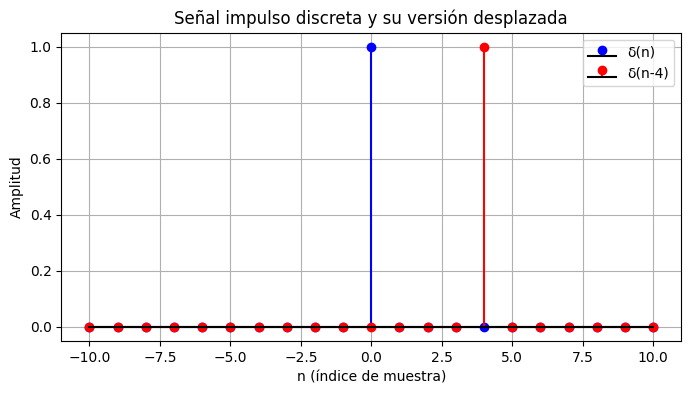

Explicación de la señal impulso:
La señal δ(n) (en azul) es un impulso discreto: vale 1 únicamente en n = 0 y 0 en el resto
de las muestras. Representa el 'ladrillo básico' con el que se puede construir cualquier
señal discreta mediante desplazamientos y escalamientos, tal como se discutió en clase.

La señal δ(n-4) (en rojo) corresponde al mismo impulso desplazado 4 muestras hacia la derecha.
Esto significa que ahora el valor 1 aparece en n = 4 en lugar de n = 0, ilustrando cómo un
desplazamiento temporal se representa simplemente cambiando el índice donde la delta es distinta de cero.


In [4]:
# Implementa una señal impulso desplazada
import numpy as np               # NumPy para manejar arreglos numéricos.
import matplotlib.pyplot as plt  # Matplotlib para graficar.

# -----------------------------
# 1) DEFINIR EJE DISCRETO n
# -----------------------------

n = np.arange(-10, 11)  
# Crea un vector de enteros desde -10 hasta 10 (incluye ambos).
# Este vector representa los índices discretos n donde definiremos la señal δ(n).

# -----------------------------
# 2) CREAR LA SEÑAL IMPULSO δ(n)
# -----------------------------

delta = np.zeros(len(n))  
# Crea un arreglo de ceros del mismo largo que 'n'. Inicialmente, la señal es todo 0.

delta[n == 0] = 1  
# Asigna el valor 1 en la posición donde n == 0.
# Esto implementa la definición de la delta discreta:
# δ(n) = 1 si n = 0, y 0 en cualquier otro n.

# -----------------------------
# 3) CREAR EL IMPULSO DESPLAZADO δ(n - n0)
# -----------------------------

n0 = 4              # Cantidad de desplazamiento hacia la derecha (en muestras).
delta_shift = np.zeros(len(n))  # Nuevo arreglo de ceros para la versión desplazada.

delta_shift[n == n0] = 1  
# Asigna 1 en la posición donde n == 4.
# Esto corresponde a δ(n - 4): el impulso se "enciende" en n = 4 en lugar de n = 0.

# -----------------------------
# 4) GRÁFICO DE AMBAS SEÑALES
# -----------------------------

plt.figure(figsize=(8, 4))  # Crea una figura de 8x4 pulgadas.

# Señal δ(n) original
plt.stem(n, delta,
         linefmt='b-',      # Estilo de línea azul.
         markerfmt='bo',    # Marcador azul en los puntos.
         basefmt='k-',      # Línea base en negro.
         label="δ(n)")      # Etiqueta para la leyenda.

# Señal δ(n - 4) desplazada
plt.stem(n, delta_shift,
         linefmt='r-',      # Estilo de línea roja para la señal desplazada.
         markerfmt='ro',    # Marcador rojo en los puntos.
         basefmt='k-',      # Misma línea base.
         label="δ(n-4)")    # Etiqueta para la leyenda.

plt.title("Señal impulso discreta y su versión desplazada")  # Título del gráfico.
plt.xlabel("n (índice de muestra)")                         # Etiqueta eje X.
plt.ylabel("Amplitud")                                      # Etiqueta eje Y.
plt.legend()                                                # Muestra la leyenda.
plt.grid(True)                                              # Activa la grilla.
plt.show()                                                  # Muestra el gráfico.

# -----------------------------
# 5) TEXTO EXPLICATIVO
# -----------------------------

print("Explicación de la señal impulso:")
print(
    "La señal δ(n) (en azul) es un impulso discreto: vale 1 únicamente en n = 0 y 0 en el resto\n"
    "de las muestras. Representa el 'ladrillo básico' con el que se puede construir cualquier\n"
    "señal discreta mediante desplazamientos y escalamientos, tal como se discutió en clase.\n"
)
print(
    "La señal δ(n-4) (en rojo) corresponde al mismo impulso desplazado 4 muestras hacia la derecha.\n"
    "Esto significa que ahora el valor 1 aparece en n = 4 en lugar de n = 0, ilustrando cómo un\n"
    "desplazamiento temporal se representa simplemente cambiando el índice donde la delta es distinta de cero."
)

### 4.2 Verificación de Nyquist
Demuestra qué sucede cuando la frecuencia de muestreo $f_s$ es menor, igual o mayor a $2 \cdot F_{max}$.

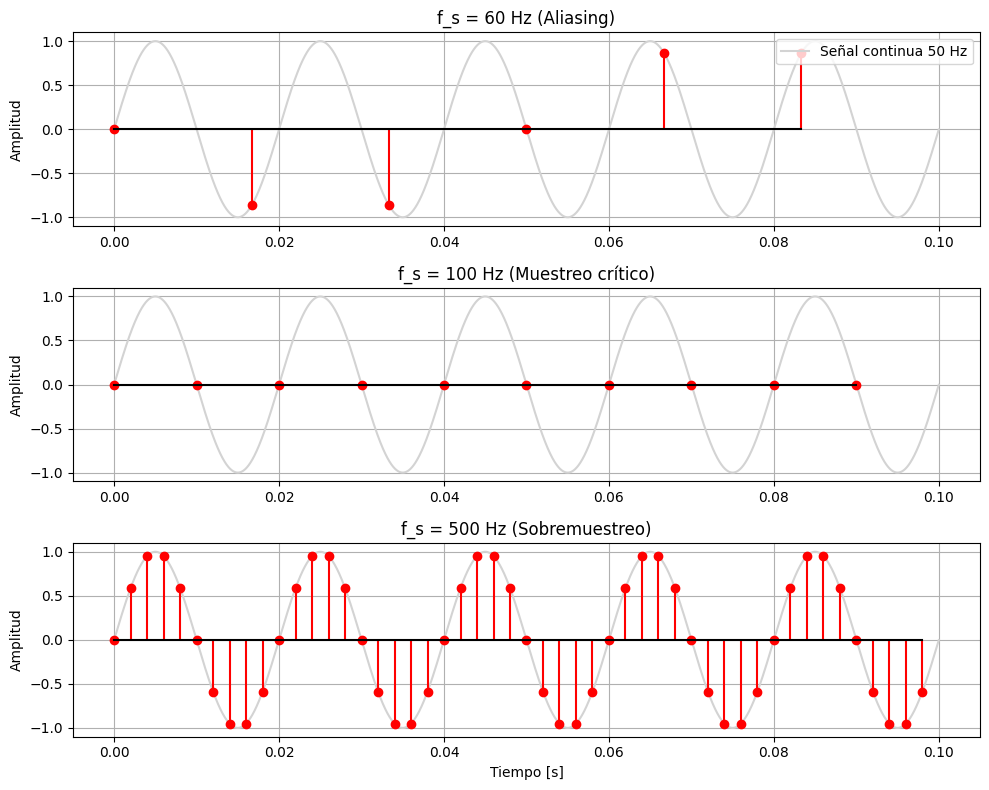

Explicación de los tres casos de muestreo:

Caso 1: f_s = 60 Hz (Aliasing):
  La señal original tiene una frecuencia de 50 Hz, por lo que el criterio de Nyquist exige
  una frecuencia de muestreo f_s ≥ 2*F_max = 100 Hz.
  Aquí se usa f_s = 60 Hz, que es menor a 100 Hz, por lo que no se cumple Nyquist.
  Las muestras caen en posiciones que, si se usaran para reconstruir la señal, generarían
  la ilusión de una frecuencia distinta (más baja) que la real de 50 Hz.
  Este efecto de 'confusión de frecuencia' se conoce como aliasing.

Caso 2: f_s = 100 Hz (Muestreo crítico):
  En este caso f_s = 2*F_max, justo en el límite del teorema de Nyquist.
  Se obtienen exactamente dos muestras por cada período de la señal de 50 Hz.
  Teóricamente es suficiente para reconstruir la frecuencia, pero la forma de la onda
  queda pobremente definida porque solo hay dos puntos por ciclo.
  No hay aliasing, pero tampoco hay margen de seguridad ante errores o filtros no ideales.

Caso 3: f_s = 500 Hz (Sobremu

In [5]:
# Evalúa 3 casos de muestreo para una senoidal de 50Hz
# f_s = 60Hz (Aliasing)
# f_s = 100Hz (Muestreo crítico)
# f_s = 500Hz (Sobremuestreo)

import numpy as np               # Importa NumPy para trabajar con arreglos numéricos (vectores, matrices, etc.).
import matplotlib.pyplot as plt  # Importa Matplotlib para generar gráficos.

# -----------------------------
# 1) PARÁMETROS DE LA SEÑAL "CONTINUA"
# -----------------------------

f_signal = 50           # Frecuencia de la señal senoidal original (F_max) en Hz.
# Esta será la frecuencia máxima de la señal que queremos samplear.

t_cont = np.linspace(0,      # Tiempo inicial en segundos (0 s).
                    0.1,    # Tiempo final en segundos (0.1 s = 100 ms).
                    10000,  # Número de puntos de tiempo muy grande → aproxima una señal "continua".
                    endpoint=False)  # endpoint=False evita incluir exactamente el punto 0.1.

# Generamos la señal de referencia "continua" usando muchos puntos.
x_cont = np.sin(2 * np.pi * f_signal * t_cont)
# Esta será la curva gris suave que representa la señal analógica de 50 Hz.

# -----------------------------
# 2) FRECUENCIAS DE MUESTREO A PROBAR
# -----------------------------

fs_list = [60, 100, 500]  
# Lista de tres frecuencias de muestreo:
#  - 60 Hz  → menor que 2*50 (100 Hz) → se espera aliasing.
#  - 100 Hz → igual a 2*50           → muestreo crítico (límite de Nyquist).
#  - 500 Hz → mucho mayor que 2*50   → sobremuestreo.

titulos = [
    "f_s = 60 Hz (Aliasing)",         # Título para el primer caso.
    "f_s = 100 Hz (Muestreo crítico)",# Título para el segundo caso.
    "f_s = 500 Hz (Sobremuestreo)"    # Título para el tercer caso.
]

# -----------------------------
# 3) CREACIÓN DE LA FIGURA
# -----------------------------

plt.figure(figsize=(10, 8))  # Crea una figura de 10 pulgadas de ancho por 8 de alto para colocar 3 subgráficos.

# -----------------------------
# 4) BUCLE SOBRE CADA f_s
# -----------------------------

for i, fs in enumerate(fs_list):   # Recorre la lista de frecuencias de muestreo con índice i y valor fs.
    
    Ts = 1 / fs                    # Calcula el periodo de muestreo (tiempo entre muestras) como el inverso de f_s.
    
    # Vector de tiempos muestreados para este caso:
    t_s = np.arange(0,      # Tiempo inicial (0 s).
                    0.1,    # Tiempo final (0.1 s, mismos 100 ms que la señal continua).
                    Ts)     # Paso entre muestras = periodo de muestreo Ts.
    # t_s contiene los instantes exactos en que el ADC "toma una muestra" de la señal analógica.
    
    # Señal muestreada: evaluamos la misma senoidal de 50 Hz, pero solo en los tiempos t_s.
    x_s = np.sin(2 * np.pi * f_signal * t_s)
    
    # Seleccionamos el subplot correspondiente a este caso.
    plt.subplot(3, 1, i + 1)  # 3 filas, 1 columna, usamos la posición i+1 (1, 2 o 3).
    
    # -----------------------------
    # 4.1 Graficar señal continua de referencia
    # -----------------------------
    
    plt.plot(t_cont, x_cont,          # Eje X: tiempos densos; eje Y: señal suave.
             color='lightgray',       # Color gris claro para la señal continua.
             label="Señal continua 50 Hz")  # Etiqueta para la leyenda.
    
    # -----------------------------
    # 4.2 Graficar las muestras discretas
    # -----------------------------
    
    # stem devuelve tres objetos: líneas de marcadores, líneas verticales y línea base.
    markerline, stemlines, baseline = plt.stem(t_s, x_s,   # Eje X: tiempos muestreados; eje Y: valores muestreados.
                                               linefmt='r-',  # Formato de línea roja que une cada muestra con el eje.
                                               markerfmt='ro',# Marcador circular rojo en cada muestra.
                                               basefmt='k-')  # Línea base negra en y = 0.
    # No se usa 'use_line_collection' para evitar problemas de compatibilidad con algunas versiones de Matplotlib.
    
    # -----------------------------
    # 4.3 Ajustes estéticos de cada subplot
    # -----------------------------
    
    plt.title(titulos[i])       # Asigna el título según el caso (aliasing, crítico, sobremuestreo).
    plt.ylabel("Amplitud")      # Etiqueta del eje vertical (amplitud de la señal).
    plt.grid(True)              # Activa la grilla para ayudar a visualizar la forma de la señal y las muestras.
    
    # Solo mostramos la leyenda en el primer subplot para que no se repita.
    if i == 0:
        plt.legend(loc="upper right")  # Muestra la leyenda en la esquina superior derecha del primer gráfico.

# -----------------------------
# 5) AJUSTES FINALES DE LA FIGURA
# -----------------------------

plt.xlabel("Tiempo [s]")   # Etiqueta del eje X común para todos los subplots (tiempo en segundos).
plt.tight_layout()         # Ajusta automáticamente los espacios entre subplots para que no se solapen.
plt.show()                 # Muestra la figura con los tres casos en pantalla.

# -----------------------------
# 6) TEXTO EXPLICATIVO DE LOS RESULTADOS
# -----------------------------

print("Explicación de los tres casos de muestreo:\n")

# Caso 1: f_s = 60 Hz (Aliasing)
print("Caso 1: f_s = 60 Hz (Aliasing):")
print(
    "  La señal original tiene una frecuencia de 50 Hz, por lo que el criterio de Nyquist exige\n"
    "  una frecuencia de muestreo f_s ≥ 2*F_max = 100 Hz.\n"
    "  Aquí se usa f_s = 60 Hz, que es menor a 100 Hz, por lo que no se cumple Nyquist.\n"
    "  Las muestras caen en posiciones que, si se usaran para reconstruir la señal, generarían\n"
    "  la ilusión de una frecuencia distinta (más baja) que la real de 50 Hz.\n"
    "  Este efecto de 'confusión de frecuencia' se conoce como aliasing.\n"
)

# Caso 2: f_s = 100 Hz (Muestreo crítico)
print("Caso 2: f_s = 100 Hz (Muestreo crítico):")
print(
    "  En este caso f_s = 2*F_max, justo en el límite del teorema de Nyquist.\n"
    "  Se obtienen exactamente dos muestras por cada período de la señal de 50 Hz.\n"
    "  Teóricamente es suficiente para reconstruir la frecuencia, pero la forma de la onda\n"
    "  queda pobremente definida porque solo hay dos puntos por ciclo.\n"
    "  No hay aliasing, pero tampoco hay margen de seguridad ante errores o filtros no ideales.\n"
)

# Caso 3: f_s = 500 Hz (Sobremuestreo)
print("Caso 3: f_s = 500 Hz (Sobremuestreo):")
print(
    "  Aquí f_s es mucho mayor que 2*F_max (500 Hz >> 100 Hz), por lo que hay muchas muestras\n"
    "  por período de la senoidal.\n"
    "  Los puntos discretos siguen de cerca la curva continua, lo que hace que la reconstrucción\n"
    "  sea más robusta y que el riesgo de aliasing sea muy bajo.\n"
    "  Visualmente, las muestras casi se apoyan sobre la señal gris de referencia.\n"
)

## 5. Cuantización y Resolución de Bits
Simularemos el proceso de discretización en amplitud.

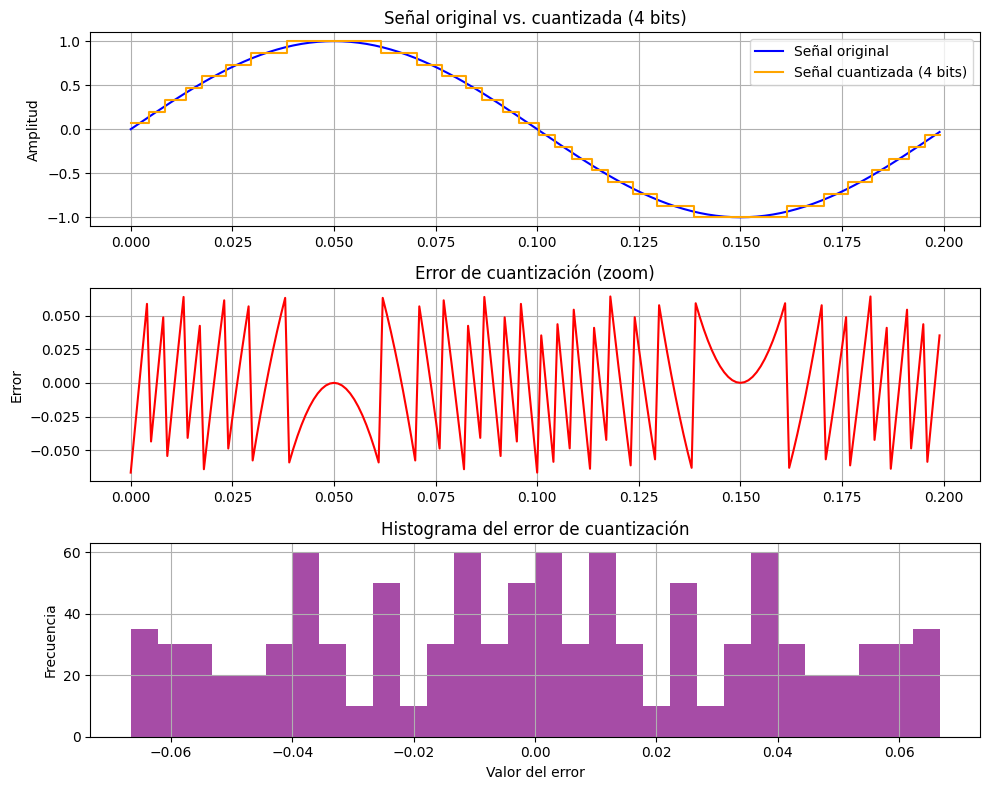

Resultados de la cuantización a 4 bits:
  Número de bits: 4
  Niveles de cuantización: 16
  Tamaño de paso Δ: 0.1333
  Potencia de la señal original: 0.5000
  Potencia del error de cuantización: 0.001358
  SNR de cuantización: 25.66 dB

Interpretación:
  - En el primer gráfico se ve que la señal cuantizada sigue la forma general de la senoidal,
    pero aparece en forma de 'escalones' porque solo se permiten 16 niveles de amplitud.

  - En el segundo gráfico, el error de cuantización muestra cuánto se desplaza cada muestra
    al nivel más cercano. Ese error permanece acotado aproximadamente entre -Δ/2 y +Δ/2.

  - En el tercer gráfico, el histograma del error se concentra alrededor de 0 y se reparte
    en el rango permitido por Δ. Esto ilustra que la cuantización introduce un ruido casi uniforme.

  - El SNR calculado indica cuántas veces la potencia de la señal es mayor que la del error de
    cuantización. Si aumentáramos el número de bits, habría más niveles, Δ sería más pequeño,


In [6]:
# Toma una señal y cuantízala a 4 bits (16 niveles).
# Calcula y grafica el SNR (Signal-to-Noise Ratio) del error de cuantización.

import numpy as np               # Importa NumPy para manejar arreglos numéricos y operaciones vectorizadas.
import matplotlib.pyplot as plt  # Importa Matplotlib para crear gráficos (líneas, histogramas, etc.).

# -----------------------------
# 1) GENERAR UNA SEÑAL ANALÓGICA DE PRUEBA
# -----------------------------

fs = 1000                        # Frecuencia de muestreo en Hz (muestras por segundo) para esta simulación.
duracion = 1.0                   # Duración total de la señal en segundos.

t = np.linspace(0,               # Tiempo inicial (0 segundos).
                duracion,        # Tiempo final (1 segundo).
                int(fs * duracion),  # Número de puntos de la señal = fs * duración (aquí 1000 puntos).
                endpoint=False)      # endpoint=False evita incluir exactamente el último punto (1.0 s).

f_senal = 5                      # Frecuencia de la señal senoidal en Hz (5 ciclos por segundo).
amplitud = 1.0                   # Amplitud máxima de la señal (oscilará entre aproximadamente -1 y 1).

# Crea la señal senoidal "original" (antes de cuantizar).
senal = amplitud * np.sin(2 * np.pi * f_senal * t)
# 2 * pi * f_senal convierte la frecuencia en rad/s, multiplicar por t da la fase,
# y sin(...) genera la forma de onda senoidal.

# -----------------------------
# 2) PARÁMETROS DE CUANTIZACIÓN A 4 BITS
# -----------------------------

bits = 4                         # Número de bits utilizados para representar cada muestra.
niveles = 2**bits                # Número de niveles de cuantización: 2^4 = 16 niveles posibles.

x_min = np.min(senal)            # Encuentra el valor mínimo de la señal original.
x_max = np.max(senal)            # Encuentra el valor máximo de la señal original.

# Calcula el tamaño del paso de cuantización (Δ).
delta = (x_max - x_min) / (niveles - 1)
# Δ es la distancia entre niveles discretos adyacentes de amplitud.

# -----------------------------
# 3) APLICAR LA CUANTIZACIÓN UNIFORME
# -----------------------------

# Paso 1: trasladar y escalar la señal al rango [0, niveles - 1].
indices_reales = (senal - x_min) / delta
# 'indices_reales' es un valor real que indica en qué nivel "caería" cada muestra antes de redondear.

# Paso 2: redondear al entero más cercano para asignar cada muestra al nivel más cercano.
indices_cuantizados = np.round(indices_reales)
# 'indices_cuantizados' ahora contiene enteros (0, 1, 2, ..., 15) antes de recorte.

# Paso 3: asegurar que los índices estén dentro del rango válido [0, niveles - 1].
indices_cuantizados = np.clip(indices_cuantizados, 0, niveles - 1)
# 'np.clip' recorta los valores que queden fuera del rango permitido.

# Paso 4: convertir de nuevo de índices de nivel a amplitud cuantizada en el rango [x_min, x_max].
senal_cuantizada = indices_cuantizados * delta + x_min
# Cada índice se multiplica por Δ y se suma x_min, reconstruyendo el valor de amplitud asociado al nivel.

# -----------------------------
# 4) CALCULAR EL ERROR DE CUANTIZACIÓN Y EL SNR
# -----------------------------

# Error de cuantización: diferencia entre la señal original y la cuantizada.
error_cuantizacion = senal - senal_cuantizada
# Este error está acotado aproximadamente entre -Δ/2 y +Δ/2 para cuantización uniforme ideal.

# Potencia de la señal original: promedio del cuadrado de sus muestras.
potencia_senal = np.mean(senal**2)

# Potencia del error de cuantización: promedio del cuadrado del error.
potencia_error = np.mean(error_cuantizacion**2)

# Cálculo del SNR (Signal-to-Noise Ratio) en decibelios.
SNR_dB = 10 * np.log10(potencia_senal / potencia_error)
# SNR_dB indica cuántas veces la potencia de la señal supera la del error de cuantización, en escala logarítmica.

# -----------------------------
# 5) GRÁFICOS: SEÑAL ORIGINAL, CUANTIZADA Y ERROR
# -----------------------------

plt.figure(figsize=(10, 8))      # Crea una figura de 10x8 pulgadas para contener 3 subgráficos.

# Para que se vea bien la forma de los escalones, mostramos solo una parte de la señal.
muestras_zoom = int(0.2 * fs)    # Número de muestras que equivalen a 0.2 segundos (20% de la señal).

# 5.1) Señal original vs. cuantizada (zoom)
plt.subplot(3, 1, 1)             # Primer subplot: 3 filas, 1 columna, posición 1.
plt.plot(t[:muestras_zoom],      # Eje X: tiempo en el intervalo reducido.
         senal[:muestras_zoom],  # Eje Y: valores de la señal original.
         label="Señal original", # Etiqueta para la leyenda.
         color='blue')           # Color azul para la señal original.

plt.step(t[:muestras_zoom],              # Eje X: mismo intervalo de tiempo.
         senal_cuantizada[:muestras_zoom],# Eje Y: señal cuantizada.
         where='mid',                     # El escalón se centra en cada intervalo.
         label="Señal cuantizada (4 bits)",# Etiqueta para la leyenda.
         color='orange')                  # Color naranja para la señal cuantizada.

plt.title("Señal original vs. cuantizada (4 bits)")  # Título del primer gráfico.
plt.ylabel("Amplitud")                               # Etiqueta del eje Y.
plt.grid(True)                                       # Activa la grilla.
plt.legend()                                         # Muestra la leyenda.

# 5.2) Error de cuantización (zoom)
plt.subplot(3, 1, 2)             # Segundo subplot: posición 2.
plt.plot(t[:muestras_zoom],      # Eje X: mismo intervalo de tiempo.
         error_cuantizacion[:muestras_zoom], # Eje Y: valores del error de cuantización.
         color='red')            # Color rojo para el error.
plt.title("Error de cuantización (zoom)")  # Título del segundo gráfico.
plt.ylabel("Error")                          # Etiqueta del eje Y.
plt.grid(True)                               # Activa la grilla.

# 5.3) Histograma del error de cuantización (toda la señal)
plt.subplot(3, 1, 3)             # Tercer subplot: posición 3.
plt.hist(error_cuantizacion,     # Datos: todos los valores del error de cuantización.
         bins=30,                # Número de barras del histograma.
         color='purple',         # Color morado para las barras.
         alpha=0.7)              # Transparencia de las barras.
plt.title("Histograma del error de cuantización")  # Título del tercer gráfico.
plt.xlabel("Valor del error")                      # Etiqueta del eje X.
plt.ylabel("Frecuencia")                           # Etiqueta del eje Y.
plt.grid(True)                                     # Activa la grilla.

plt.tight_layout()         # Ajusta los subplots para que no se sobrepongan.
plt.show()                 # Muestra la figura con los tres gráficos.

# -----------------------------
# 6) TEXTO EXPLICATIVO (SNR Y RESULTADOS)
# -----------------------------

print("Resultados de la cuantización a 4 bits:")
print(f"  Número de bits: {bits}")                     # Muestra el número de bits usados.
print(f"  Niveles de cuantización: {niveles}")         # Muestra cuántos niveles discretos hay.
print(f"  Tamaño de paso Δ: {delta:.4f}")              # Muestra el valor de Δ con 4 decimales.
print(f"  Potencia de la señal original: {potencia_senal:.4f}")  # Muestra la potencia de la señal.
print(f"  Potencia del error de cuantización: {potencia_error:.6f}")  # Muestra la potencia del error.
print(f"  SNR de cuantización: {SNR_dB:.2f} dB\n")     # Muestra el SNR en decibelios.

print("Interpretación:")
print(
    "  - En el primer gráfico se ve que la señal cuantizada sigue la forma general de la senoidal,\n"
    "    pero aparece en forma de 'escalones' porque solo se permiten 16 niveles de amplitud.\n"
)
print(
    "  - En el segundo gráfico, el error de cuantización muestra cuánto se desplaza cada muestra\n"
    "    al nivel más cercano. Ese error permanece acotado aproximadamente entre -Δ/2 y +Δ/2.\n"
)
print(
    "  - En el tercer gráfico, el histograma del error se concentra alrededor de 0 y se reparte\n"
    "    en el rango permitido por Δ. Esto ilustra que la cuantización introduce un ruido casi uniforme.\n"
)
print(
    "  - El SNR calculado indica cuántas veces la potencia de la señal es mayor que la del error de\n"
    "    cuantización. Si aumentáramos el número de bits, habría más niveles, Δ sería más pequeño,\n"
    "    el error disminuiría y el SNR aumentaría, mejorando el rango dinámico del sistema.\n"
)

## 6. Análisis de Vibraciones: Caso de Ingeniería
Un motor gira a 60 Hz (rotación normal) pero tiene una falla de desalineación que genera un componente de 120 Hz. El entorno tiene mucho ruido.

**Tarea:**
1. Genera la señal mixta ruidosa.
2. Identifica las frecuencias mediante la FFT.

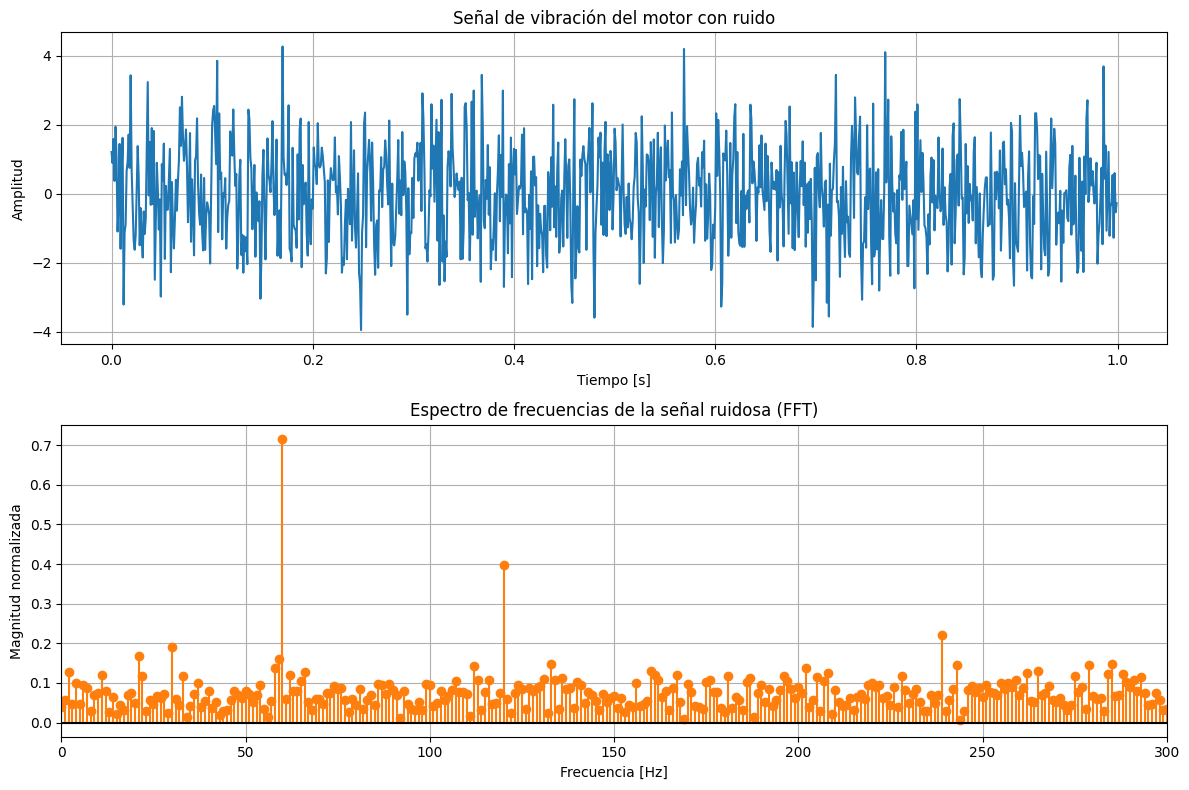

Análisis de vibraciones (motor a 60 Hz con falla a 120 Hz):

Dominio del tiempo:
  La señal ruidosa mezcla dos componentes senoidales (60 Hz y 120 Hz) con ruido blanco gaussiano.
  Por eso la forma en el tiempo se ve irregular y no claramente periódica.

Dominio de la frecuencia (FFT):
  En el espectro aparecen picos notables cerca de 60 Hz y 120 Hz.
  El pico en 60 Hz corresponde a la velocidad de rotación normal del motor.
  El pico en 120 Hz corresponde a la frecuencia asociada a la falla de desalineación.
  El resto del espectro, de menor amplitud y más extendido, corresponde al ruido de fondo.



In [7]:
# fs = 1000
#  t = np.linspace(0, 1, fs)
# f_rotation = 60
# f_fault = 120

# Señal con ruido blanco gaussiano
# signal_clean = 0.7 * np.sin(2 * np.pi * f_rotation * t) + 0.4 * np.sin(2 * np.pi * f_fault * t)
# noisy_signal = signal_clean + np.random.normal(0, 1.2, len(t))

# Aplica FFT y grafica

import numpy as np                # Librería para cálculos numéricos con arreglos.
import matplotlib.pyplot as plt   # Librería para generar gráficos.
from scipy.fft import fft, fftfreq  # Funciones para calcular la FFT y el eje de frecuencias.

# -----------------------------
# 1) PARÁMETROS ENTREGADOS
# -----------------------------

fs = 1000                         # Frecuencia de muestreo en Hz (1000 muestras por segundo).
t = np.linspace(0,                # Tiempo inicial (0 s).
                1,                # Tiempo final (1 s).
                fs,               # Número de puntos (fs = 1000 puntos en 1 segundo).
                endpoint=False)   # No incluir el punto final exactamente en 1.0 s.

f_rotation = 60                   # Frecuencia de rotación normal del motor en Hz.
f_fault = 120                     # Frecuencia asociada a la falla de desalineación en Hz.

# -----------------------------
# 2) SEÑAL LIMPIA (SIN RUIDO)
# -----------------------------

signal_clean = (0.7 * np.sin(2 * np.pi * f_rotation * t) +   # Componente senoidal a 60 Hz con amplitud 0.7.
                0.4 * np.sin(2 * np.pi * f_fault * t))       # Componente senoidal a 120 Hz con amplitud 0.4.

# -----------------------------
# 3) AÑADIR RUIDO BLANCO GAUSSIANO
# -----------------------------

noisy_signal = signal_clean + np.random.normal(0,   # Media 0 (ruido centrado).
                                               1.2, # Desviación estándar del ruido (intensidad del ruido).
                                               len(t))  # Número de muestras de ruido igual al largo de la señal.

# -----------------------------
# 4) CÁLCULO DE LA FFT
# -----------------------------

N = len(noisy_signal)            # Número total de muestras (N = 1000).

Y = fft(noisy_signal)            # Calcula la FFT compleja de la señal ruidosa.
# 'Y' contiene amplitud y fase de cada componente de frecuencia.

freqs = fftfreq(N, 1/fs)         # Calcula el vector de frecuencias asociado a la FFT.
# 'freqs' incluye frecuencias positivas y negativas.

# Nos quedamos solo con las frecuencias positivas (lado único).
mask_pos = freqs >= 0            # Máscara booleana para frecuencias >= 0.
freqs_pos = freqs[mask_pos]      # Frecuencias no negativas.
Y_pos = Y[mask_pos]              # Valores de la FFT en esas frecuencias.

# Magnitud normalizada del espectro (lado único).
mag_pos = (2.0 / N) * np.abs(Y_pos)
# np.abs(Y_pos) calcula la magnitud de los coeficientes complejos.
# El factor 2.0/N normaliza la amplitud para señales reales.

# -----------------------------
# 5) GRÁFICOS: SEÑAL Y ESPECTRO
# -----------------------------

plt.figure(figsize=(12, 8))      # Crea una figura de 12x8 pulgadas con 2 subgráficos.

# 5.1) Señal ruidosa en el tiempo
plt.subplot(2, 1, 1)             # Primer subplot (2 filas, 1 columna, posición 1).
plt.plot(t, noisy_signal,        # Eje X: tiempo; Eje Y: señal ruidosa.
         color='tab:blue')       # Color azul.
plt.title("Señal de vibración del motor con ruido")  # Título del primer gráfico.
plt.xlabel("Tiempo [s]")         # Etiqueta del eje X.
plt.ylabel("Amplitud")           # Etiqueta del eje Y.
plt.grid(True)                   # Activa la grilla.

# 5.2) Espectro de magnitud (FFT)
plt.subplot(2, 1, 2)             # Segundo subplot (posición 2).
markerline, stemlines, baseline = plt.stem(
    freqs_pos,                   # Eje X: frecuencias positivas.
    mag_pos,                     # Eje Y: magnitud normalizada.
    linefmt='tab:orange',        # Color de las líneas verticales.
    markerfmt='o',               # Marcador circular.
    basefmt='k-')                # Línea base en negro.

plt.title("Espectro de frecuencias de la señal ruidosa (FFT)")  # Título del segundo gráfico.
plt.xlabel("Frecuencia [Hz]")   # Etiqueta del eje X.
plt.ylabel("Magnitud normalizada")  # Etiqueta del eje Y.
plt.xlim(0, 300)                # Zoom de 0 a 300 Hz (donde caen 60 y 120 Hz).
plt.grid(True)                  # Activa la grilla.

plt.tight_layout()              # Ajusta automáticamente los subplots.
plt.show()                      # Muestra la figura.

# -----------------------------
# 6) TEXTO EXPLICATIVO
# -----------------------------

print("Análisis de vibraciones (motor a 60 Hz con falla a 120 Hz):\n")

print("Dominio del tiempo:")
print(
    "  La señal ruidosa mezcla dos componentes senoidales (60 Hz y 120 Hz) con ruido blanco gaussiano.\n"
    "  Por eso la forma en el tiempo se ve irregular y no claramente periódica.\n"
)

print("Dominio de la frecuencia (FFT):")
print(
    "  En el espectro aparecen picos notables cerca de 60 Hz y 120 Hz.\n"
    "  El pico en 60 Hz corresponde a la velocidad de rotación normal del motor.\n"
    "  El pico en 120 Hz corresponde a la frecuencia asociada a la falla de desalineación.\n"
    "  El resto del espectro, de menor amplitud y más extendido, corresponde al ruido de fondo.\n"
)

## 7. Frecuencia Espacial en Imágenes
Las imágenes también tienen frecuencias. Cambios rápidos (bordes) son altas frecuencias; áreas suaves son bajas frecuencias.

**Tarea:**
1. Genera una rejilla senoidal (sinusoidal grating).
2. Aplica la FFT 2D y observa el espectro centrado.

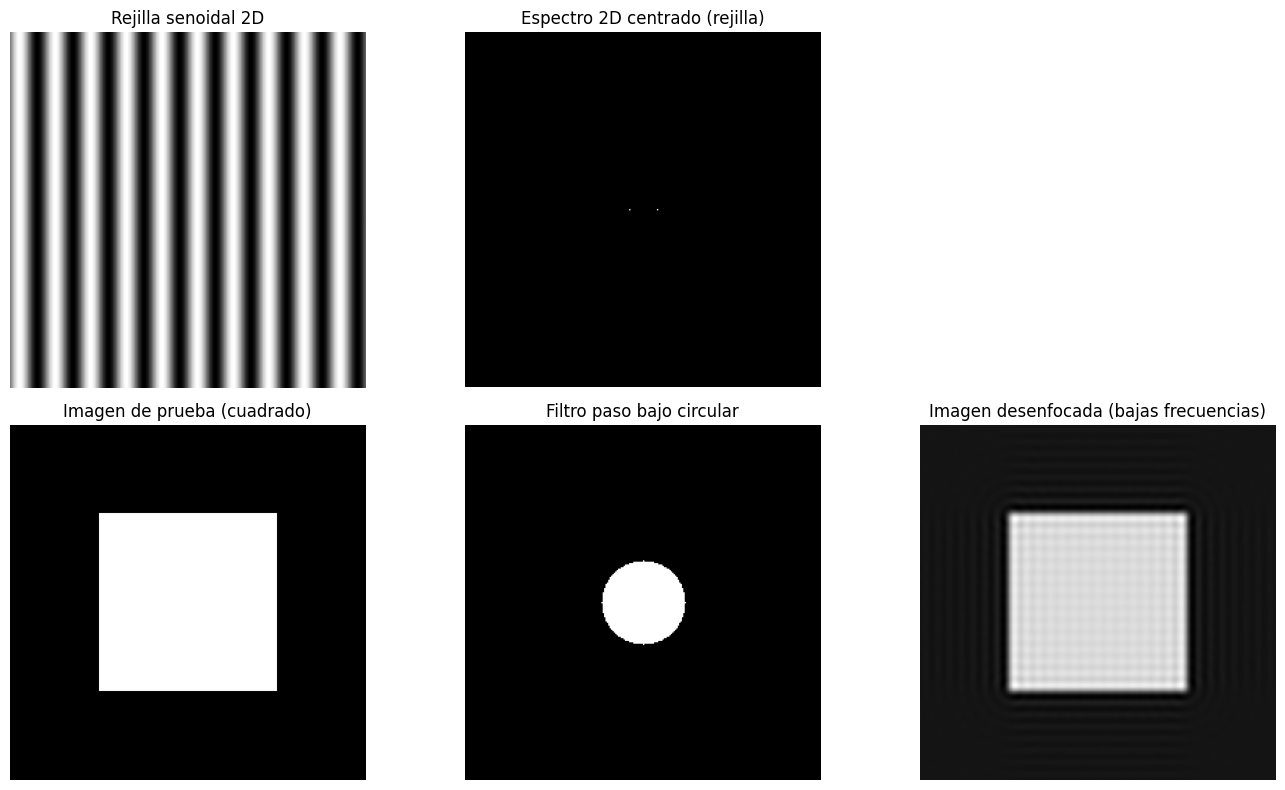

Frecuencia espacial en imágenes:

Rejilla senoidal y su espectro:
  - La rejilla senoidal 2D muestra bandas verticales claras y oscuras que cambian rápidamente
    en dirección X. Esto corresponde a una frecuencia espacial alta en X y casi nula en Y.

  - En el espectro 2D centrado aparecen dos picos simétricos alejados del centro en el eje horizontal,
    que representan esa frecuencia espacial específica de la rejilla.

Filtro paso bajo circular:
  - La máscara circular deja pasar solo las frecuencias cercanas al centro del espectro (bajas frecuencias)
    y atenúa el resto (altas frecuencias, asociadas a bordes y detalles finos).

  - Al aplicar la inversa de la FFT, la imagen resultante aparece desenfocada: los bordes del cuadrado
    se suavizan porque se eliminaron las componentes de alta frecuencia que definían los cambios bruscos.



In [8]:
# 1. Generar rejilla senoidal 2D (np.meshgrid).
# 2. Calcular FFT2 y aplicar fftshift.
# 3. Implementar un filtro de paso bajo circular para desenfocar una imagen de prueba.

import numpy as np                  # NumPy para trabajar con matrices y operaciones numéricas.
import matplotlib.pyplot as plt     # Matplotlib para visualizar imágenes y espectros.
from scipy.fft import fft2, fftshift, ifft2  # FFT 2D, centrado del espectro e inversa 2D.

# -----------------------------
# 1) GENERAR UNA REJILLA SENOIDA 2D (SINUSOIDAL GRATING)
# -----------------------------

# Definimos el tamaño de la imagen sintética (matriz cuadrada).
N = 256                             # Tamaño de la imagen: 256 x 256 píxeles.

# Creamos un eje de coordenadas espaciales en X e Y.
x = np.linspace(0, 1, N, endpoint=False)   # Coordenadas normalizadas en X (0 a 1).
y = np.linspace(0, 1, N, endpoint=False)   # Coordenadas normalizadas en Y (0 a 1).

# Generamos una malla 2D con todas las combinaciones (X,Y).
X, Y = np.meshgrid(x, y)            # X e Y son matrices N x N con las coordenadas correspondientes.

# Definimos frecuencias espaciales de la rejilla (número de ciclos por unidad de distancia).
fx = 10                             # Frecuencia espacial en dirección X (10 ciclos horizontales).
fy = 0                              # Frecuencia espacial en dirección Y (0 → bandas verticales).

# Creamos la rejilla senoidal 2D.
grating = np.sin(2 * np.pi * (fx * X + fy * Y))
# Cada fila de la imagen tendrá una variación senoidal en X: bandas claras/oscuras verticales.

# -----------------------------
# 2) CALCULAR LA FFT 2D Y CENTRAR EL ESPECTRO
# -----------------------------

# Calculamos la transformada de Fourier 2D de la rejilla.
F_grating = fft2(grating)
# F_grating es una matriz compleja N x N que representa el contenido de frecuencias espaciales.

# Centramos el espectro para que la frecuencia (0,0) quede en el centro de la imagen.
F_grating_shifted = fftshift(F_grating)

# Calculamos la magnitud (módulo) del espectro.
magnitude_spectrum = np.abs(F_grating_shifted)

# Usamos escala logarítmica para mejorar la visibilidad de las componentes.
magnitude_spectrum_log = np.log(magnitude_spectrum + 1)
# +1 evita problemas de log(0).

# -----------------------------
# 3) CREAR UNA IMAGEN DE PRUEBA Y APLICAR FILTRO PASO BAJO CIRCULAR
# -----------------------------

# Creamos una imagen de prueba: por simplicidad, una combinación de patrones (tipo "textura").
# (En una tarea real podrías cargar una imagen real en escala de grises).
image = np.zeros((N, N))                 # Inicializamos una imagen N x N en negro.

# Dibujamos un cuadrado blanco en el centro como "objeto" de prueba.
image[N//4:3*N//4, N//4:3*N//4] = 1.0    # Rellenamos un bloque central con valor 1 (blanco).

# Calculamos la FFT 2D de la imagen de prueba.
F_image = fft2(image)

# Centramos el espectro de la imagen.
F_image_shifted = fftshift(F_image)

# Definimos el radio del filtro paso bajo (en píxeles).
radio = 30                               # Radio del círculo de frecuencias bajas que vamos a conservar.

# Creamos una máscara circular del mismo tamaño que la imagen.
mask = np.zeros((N, N))                  # Máscara inicializada en 0 (rechaza todo).
cx, cy = N // 2, N // 2                  # Coordenadas del centro de la imagen (y del espectro).

# Recorremos todos los píxeles para marcar los que estén dentro del radio.
for i in range(N):                       # Recorre filas.
    for j in range(N):                   # Recorre columnas.
        # Distancia al centro en el espacio de frecuencias.
        dist2 = (i - cy)**2 + (j - cx)**2
        if dist2 <= radio**2:
            mask[i, j] = 1.0            # Dentro del círculo → dejar pasar (frecuencias bajas).

# Aplicamos el filtro paso bajo multiplicando la FFT centrada por la máscara.
F_image_low = F_image_shifted * mask

# Volvemos a desplazar el espectro filtrado a la forma original (sin centrar).
F_image_low_unshift = fftshift(F_image_low)

# Calculamos la transformada inversa 2D para volver al dominio espacial.
image_blurred_complex = ifft2(F_image_low_unshift)

# Nos quedamos con la parte real (la parte imaginaria idealmente es muy pequeña).
image_blurred = np.real(image_blurred_complex)

# -----------------------------
# 4) VISUALIZACIÓN DE RESULTADOS
# -----------------------------

plt.figure(figsize=(14, 8))  # Creamos una figura grande para varios subgráficos.

# 4.1) Rejilla senoidal 2D
plt.subplot(2, 3, 1)         # Primer subplot (2 filas, 3 columnas, posición 1).
plt.imshow(grating,          # Imagen de la rejilla senoidal.
           cmap='gray',      # Mapa de color en escala de grises.
           extent=(0, 1, 0, 1))  # Escala de ejes (0 a 1 en X e Y).
plt.title("Rejilla senoidal 2D")
plt.axis('off')              # Oculta ejes.

# 4.2) Espectro 2D centrado de la rejilla (magnitud logarítmica)
plt.subplot(2, 3, 2)         # Segundo subplot.
plt.imshow(magnitude_spectrum_log, cmap='gray')
plt.title("Espectro 2D centrado (rejilla)")
plt.axis('off')

# 4.3) Imagen de prueba original (cuadrado blanco)
plt.subplot(2, 3, 4)         # Tercer subplot.
plt.imshow(image, cmap='gray')
plt.title("Imagen de prueba (cuadrado)")
plt.axis('off')

# 4.4) Máscara del filtro paso bajo circular
plt.subplot(2, 3, 5)         # Cuarto subplot.
plt.imshow(mask, cmap='gray')
plt.title("Filtro paso bajo circular")
plt.axis('off')

# 4.5) Imagen desenfocada (después del filtro paso bajo)
plt.subplot(2, 3, 6)         # Quinto subplot.
plt.imshow(image_blurred, cmap='gray')
plt.title("Imagen desenfocada (bajas frecuencias)")
plt.axis('off')

plt.tight_layout()           # Ajusta los subplots para que no se solapen.
plt.show()                   # Muestra la figura completa.

# -----------------------------
# 5) TEXTO EXPLICATIVO
# -----------------------------

print("Frecuencia espacial en imágenes:\n")

print("Rejilla senoidal y su espectro:")
print(
    "  - La rejilla senoidal 2D muestra bandas verticales claras y oscuras que cambian rápidamente\n"
    "    en dirección X. Esto corresponde a una frecuencia espacial alta en X y casi nula en Y.\n"
)
print(
    "  - En el espectro 2D centrado aparecen dos picos simétricos alejados del centro en el eje horizontal,\n"
    "    que representan esa frecuencia espacial específica de la rejilla.\n"
)

print("Filtro paso bajo circular:")
print(
    "  - La máscara circular deja pasar solo las frecuencias cercanas al centro del espectro (bajas frecuencias)\n"
    "    y atenúa el resto (altas frecuencias, asociadas a bordes y detalles finos).\n"
)
print(
    "  - Al aplicar la inversa de la FFT, la imagen resultante aparece desenfocada: los bordes del cuadrado\n"
    "    se suavizan porque se eliminaron las componentes de alta frecuencia que definían los cambios bruscos.\n"
)

## 8. Conclusiones y Preguntas Teóricas
- ¿Cómo afecta la desviación estándar del ruido gaussiano a la legibilidad del espectro en la FFT?
- Explica por qué un cambio brusco de color en una imagen (un borde) genera componentes de alta frecuencia en el espectro 2D.
- ¿Qué relación existe entre la resolución de cuantización y el rango dinámico de un sistema de audio?

¿Cómo afecta la desviación estándar del ruido gaussiano a la legibilidad del espectro en la FFT?


Cuando se añade ruido gaussiano a una señal, la desviación estándar 
σ
σ del ruido controla directamente su potencia promedio: a mayor 
σ
σ, mayor energía total del ruido distribuida a lo largo de las frecuencias. Desde el punto de vista espectral, esto se traduce en un incremento del “piso de ruido” (noise floor), es decir, el nivel mínimo de energía que aparece en casi todas las frecuencias aunque no exista componente determinista allí. Si la señal original tiene picos espectrales bien definidos (por ejemplo, una senoidal pura o un conjunto de armónicos mecánicos), mientras 
σ
σ sea relativamente pequeña, esos picos sobresalen con buena relación señal‑ruido y pueden detectarse e identificarse sin dificultad. Sin embargo, cuando 
σ
σ aumenta significativamente, el nivel del piso de ruido se eleva hasta acercarse o incluso superar la altura de esos picos; en ese régimen, las componentes espectrales de la señal quedan parcial o totalmente enmascaradas por el ruido y la FFT pierde capacidad de revelar líneas espectrales estrechas, volviéndose más difícil distinguir, por ejemplo, la frecuencia de una falla mecánica de la “alfombra” espectral de ruido que la rodea. En aplicaciones de diagnóstico (vibraciones, bioseñales, radioastronomía, etc.), esto obliga a trabajar con medidas de SNR, técnicas de promediado y filtrado, porque una 
σ
σ demasiado grande puede hacer que una banda de interés deje de ser visible en el espectro aunque la señal siga existiendo físicamente.

Explica por qué un cambio brusco de color en una imagen (un borde) genera componentes de alta frecuencia en el espectro 2D.


En términos matemáticos, una imagen bidimensional puede interpretarse como una función \(f(x,y)\) definida sobre una grilla de píxeles, donde los cambios suaves de intensidad corresponden a variaciones lentas en el espacio y los bordes a transiciones abruptas casi discontinuas. Desde el punto de vista de la Transformada de Fourier 2D, representar una transición casi escalón (por ejemplo, pasar de negro a blanco en uno o dos píxeles) requiere mezclar un número muy grande de componentes seno y coseno de periodos espaciales cortos; esto es exactamente lo que se entiende por altas frecuencias espaciales. De forma intuitiva, una región uniforme de color constante se puede aproximar solo con unas pocas componentes muy cercanas al origen del plano de frecuencias (bajas frecuencias), porque no hay detalles ni oscilaciones rápidas en el nivel de gris. En cambio, un borde “afilado” implica que en muy pocas celdas de la matriz la intensidad cambia fuertemente; para reproducir ese salto con combinaciones de ondas continuas se necesitan senoidales que oscilen muy rápido en la dirección perpendicular al borde, lo que en el espectro 2D se manifiesta como energía concentrada lejos del centro (a distancias mayores en el eje \(u,v\)). Por eso, cuando se observa el espectro centrado de una imagen con bordes dominantes, aparecen estructuras alargadas o picos en las regiones de alta frecuencia orientadas según la geometría de esos bordes.

¿Qué relación existe entre la resolución de cuantización y el rango dinámico de un sistema de audio?



La resolución de cuantización, medida en bits por muestra, determina cuántos niveles discretos están disponibles para representar la amplitud de la señal analógica una vez digitalizada: con \(B\) bits se obtienen 
2
B
2 
B
  niveles posibles. Cuantos más niveles existen, menor es el paso de cuantización 
Δ
Δ y, por lo tanto, más pequeño es el error de redondeo al asignar cada muestra al nivel más cercano; este error se modela como ruido de cuantización y su potencia disminuye aproximadamente de forma cuadrática con 
Δ
Δ. El rango dinámico de un sistema de audio se define como la diferencia, en decibelios, entre el nivel máximo reproducible sin saturación y el nivel del ruido de fondo (que incluye el ruido de cuantización); si el ruido de cuantización baja, la diferencia entre “lo más fuerte” que se puede grabar y “el piso de ruido” aumenta. En la práctica, para cuantización uniforme ideal, se suele aproximar que cada bit adicional incrementa el rango dinámico alrededor de 6 dB, es decir, doblando aproximadamente la relación entre la potencia de la señal máxima y la potencia del ruido. Esto explica por qué sistemas de 8 bits (como audio muy básico) presentan un ruido perceptible en pasajes silenciosos, mientras que formatos de 16 o 24 bits permiten capturar matices muy débiles sin que queden sumergidos en el ruido de cuantización, logrando grabaciones con gran margen entre los sonidos más suaves y los más intensos sin degradación audible.

## 9. Referencias

[Generate colors of noise in Python] https://stackoverflow.com/questions/67085963/generate-colors-of-noise-in-python

[Generación de señales] https://medium.com/@martinkarlsson.io/fourier-transform-in-python-f15b3243ce9a

[Fourier Transform] https://pythonnumericalmethods.berkeley.edu/notebooks/chapter24.04-FFT-in-Python.html

[SciPy] https://docs.scipy.org/doc/scipy/tutorial/fft.html

[Fourier con numpy] https://towardsdatascience.com/fourier-transform-the-practical-python-implementation-acdd32f1b96a

[Sobre Teorema del sampleo] https://ipython-books.github.io/chapter-10-signal-processing/

[Sobre Matplotlib] https://matplotlib.org/stable/gallery/mplot3d/2dcollections3d.html

[2D meshing] https://thepythoncodingbook.com/2021/08/30/2d-fourier-transform-in-python-and-fourier-synthesis-of-images/

[Numerical Methods] https://pythonnumericalmethods.berkeley.edu/notebooks/Index.html